In [1]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam0
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam1
INFO     | setup | Train Dataset       : 40 samples
INFO     | _get_names | Processing val
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam0
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam1
INFO     | setup | Validation Dataset  : 40 samples


In [5]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints = batch

ref_patches = ref_patches.unsqueeze(1)
tar_patches = tar_patches.unsqueeze(1)

print(f'{ref_patches.shape}')
print(f'{ref_keypoints.shape}')
print(f'{tar_patches.shape}')
print(f'{tar_keypoints.shape}')

torch.Size([5, 1, 128, 128])
torch.Size([5, 2])
torch.Size([5, 1, 128, 128])
torch.Size([5, 2])


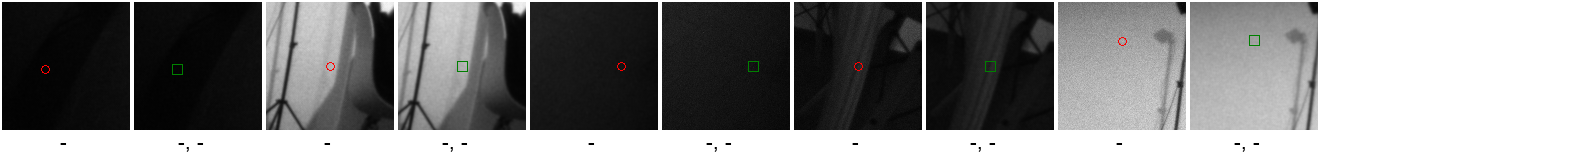

In [6]:
count = 24 * 1

show_batch(
    ref_patches, tar_patches,
    ref_keypoints, tar_keypoints,
    tar_keypoints,
    
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

In [7]:
print(ref_keypoints[:10])

print(tar_keypoints[:10])

tensor([[43., 67.],
        [64., 64.],
        [91., 64.],
        [64., 64.],
        [64., 39.]])
tensor([[43., 67.],
        [64., 64.],
        [91., 64.],
        [64., 64.],
        [64., 38.]])
